In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

In [27]:
df = pd.read_csv("loan_data.csv")

In [42]:
print(df.columns)

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='object')


In [28]:
x = df.drop(columns=["loan_status"])
y = df["loan_status"]

In [29]:
print("Target values:", y.unique()) 

Target values: [1 0]


In [30]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=42)

In [32]:
num_cols = x.select_dtypes(include='number').columns
obj_cols = x.select_dtypes(include='object').columns

In [ ]:
scaler = MinMaxScaler()
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

In [34]:
xtrain[num_cols] = scaler.fit_transform(xtrain[num_cols])
xtest[num_cols] = scaler.transform(xtest[num_cols])

In [35]:
encoded_train = encoder.fit_transform(xtrain[obj_cols])
encoded_test = encoder.transform(xtest[obj_cols])
encoded_cols = encoder.get_feature_names_out(obj_cols)

In [36]:
xtrain[encoded_cols] = encoded_train
xtest[encoded_cols] = encoded_test


In [37]:
xtrain.drop(columns=obj_cols, inplace=True)
xtest.drop(columns=obj_cols, inplace=True)


In [38]:
model = LogisticRegression(max_iter=200)
model.fit(xtrain, ytrain)

LogisticRegression(max_iter=200)

In [39]:
ypred = model.predict(xtest)

In [40]:
cm = confusion_matrix(ytest, ypred)
print("Confusion Matrix:\n", cm)

print("\nPrecision:", precision_score(ytest, ypred))
print("Recall:", recall_score(ytest, ypred))
print("F1 Score:", f1_score(ytest, ypred))
print("Accuracy:", accuracy_score(ytest, ypred))

Confusion Matrix:
 [[6548  442]
 [ 523 1487]]

Precision: 0.7708657335406947
Recall: 0.7398009950248756
F1 Score: 0.755013962934755
Accuracy: 0.8927777777777778


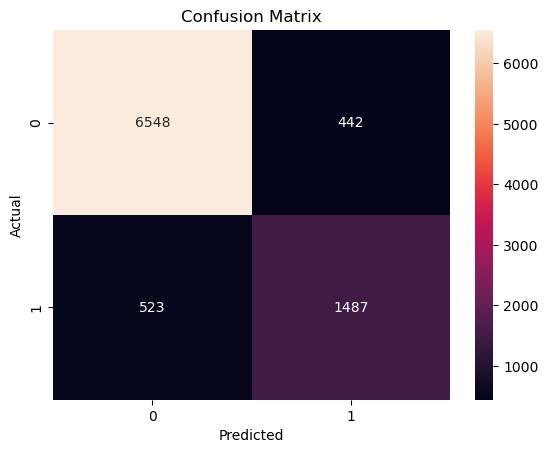

In [41]:
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
ytrain_pred=model.predict(xtrain)
confusion_matrix(ytrain,ytrain_pred)
